In [1]:
import requests
import time
import random
import gspread
from datetime import datetime
from bs4 import BeautifulSoup
from oauth2client.service_account import ServiceAccountCredentials
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
SCRAPER_API_KEY = "43c4ca09b4a98b85e92d97377d03ee00"

In [3]:
# Set up Google Sheets API authentication
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/drive"]
creds = ServiceAccountCredentials.from_json_keyfile_name("credentials.json", scope)
client = gspread.authorize(creds)

In [4]:
# Open Google Sheet (replace with your sheet name)
sheet = client.open("Ecommerce Demand Data").sheet1

In [ ]:
# 🔍 E-Commerce Platforms URLs (Search Query Placeholder: {query})
E_COMMERCE_SITES = {
     "Amazon": f"http://api.scraperapi.com?api_key={SCRAPER_API_KEY}&url=https://www.amazon.com/s?k={{query}}",
    "eBay": f"http://api.scraperapi.com?api_key={SCRAPER_API_KEY}&url=https://www.ebay.com/sch/i.html?_nkw={{query}}",
    "Flipkart": f"http://api.scraperapi.com?api_key={SCRAPER_API_KEY}&url=https://www.flipkart.com/search?q={{query}}",
    "Walmart": f"http://api.scraperapi.com?api_key={SCRAPER_API_KEY}&url=https://www.walmart.com/search?q={{query}}",
    "Alibaba": f"http://api.scraperapi.com?api_key={SCRAPER_API_KEY}&url=https://www.alibaba.com/trade/search?SearchText={{query}}",
    "eBay": f"http://api.scraperapi.com?api_key={SCRAPER_API_KEY}&url=https://www.ebay.com/sch/i.html?_nkw={{query}}"
}



In [ ]:
def fetch_html(url):
    try:
        response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
        if response.status_code == 200:
            return response.text
        else:
            print(f"Error {response.status_code}: Failed to fetch {url}")
            return None
    except Exception as e:
        print(f"Exception: {e}")
        return None
    
    

In [ ]:
def parse_amazon(html):
    soup = BeautifulSoup(html, "html.parser")
    products = []

    for item in soup.select(".s-result-item"):
        title = item.select_one("h2 a span")
        price = item.select_one(".a-price-whole")
        rating = item.select_one(".a-icon-alt")

        if title and price:
            products.append([
                title.text.strip(),
                random.randint(50, 300),  # Simulating No. of Times Searched
                "Amazon",
                random.randint(10, 100),  # Estimated Ordered Quantity
                f"${price.text.strip()}",
                rating.text.split(" ")[0] if rating else "N/A"
            ])

    return products



In [ ]:
def parse_ebay(html):
    soup = BeautifulSoup(html, "html.parser")
    products = []

    for item in soup.select(".s-item"):
        title = item.select_one(".s-item__title")
        price = item.select_one(".s-item__price")
        rating = item.select_one(".s-item__reviews span")

        if title and price:
            products.append([
                title.text.strip(),
                random.randint(50, 300),
                "eBay",
                random.randint(10, 100),
                price.text.strip(),
                rating.text.strip() if rating else "N/A"
            ])

    return products



In [ ]:
def parse_flipkart(html):
    soup = BeautifulSoup(html, "html.parser")
    products = []

    for item in soup.select("._1AtVbE"):
        title = item.select_one("._4rR01T")
        price = item.select_one("._30jeq3")
        rating = item.select_one("._3LWZlK")

        if title and price:
            products.append([
                title.text.strip(),
                random.randint(50, 300),
                "Flipkart",
                random.randint(10, 100),
                price.text.strip(),
                rating.text.strip() if rating else "N/A"
            ])

    return products



In [ ]:
def parse_walmart(html):
    soup = BeautifulSoup(html, "html.parser")
    products = []

    for item in soup.select(".search-result-gridview-item"):
        title = item.select_one(".product-title-link")
        price = item.select_one(".price-main .visuallyhidden")
        rating = item.select_one(".seo-avg-rating")

        if title and price:
            products.append([
                title.text.strip(),
                random.randint(50, 300),
                "Walmart",
                random.randint(10, 100),
                price.text.strip(),
                rating.text.strip() if rating else "N/A"
            ])

    return products



In [ ]:
def parse_alibaba(html):
    soup = BeautifulSoup(html, "html.parser")
    products = []

    for item in soup.select(".J-offer-wrapper"):
        title = item.select_one(".elements-title-normal")
        price = item.select_one(".elements-offer-price-normal__price")
        rating = item.select_one(".seb-supplier-review__score")

        if title and price:
            products.append([
                title.text.strip(),
                random.randint(50, 300),
                "Alibaba",
                random.randint(10, 100),
                price.text.strip(),
                rating.text.strip() if rating else "N/A"
            ])

    return products



In [ ]:
# Collect & Save Data
def collect_and_save_data():
    search_queries = [ "iphone 16"]

    for query in search_queries:
        for platform, base_url in E_COMMERCE_SITES.items():
            search_url = base_url.format(query=query.replace(" ", "+"))
            print(f"Searching for '{query}' on {platform}...")

            html_content = fetch_html(search_url)

            if html_content:
                
                if platform == "eBay":
                    product_data = parse_ebay(html_content)
                
                else:
                    product_data = []

                if product_data:
                    sheet.append_rows(product_data)
                    print(f"{len(product_data)} products added from {platform}.")
                else:
                    print(f"No products found on {platform}.")

            time.sleep(5)  # Avoid rate limits

    print("All product data successfully saved!")

# Run the scraper
collect_and_save_data()



Searching for 'iphone 16' on Amazon...
No products found on Amazon.
Searching for 'iphone 16' on eBay...
66 products added from eBay.
Searching for 'iphone 16' on Flipkart...
No products found on Flipkart.
Searching for 'iphone 16' on Walmart...
No products found on Walmart.
Searching for 'iphone 16' on Alibaba...
No products found on Alibaba.
All product data successfully saved!


In [13]:
""" 
    "Realme GT Neo", "Motorola Edge 30", "Asus ROG Phone 7", "Nothing Phone 2", "Sony Xperia 1 V",

    # Laptops
    "MacBook Air", "Dell Inspiron", "HP Pavilion Laptop", "Asus ROG Laptop", "MSI Gaming Laptop",
    "Lenovo ThinkPad", "Razer Blade 15", "Acer Predator Helios", "Samsung Galaxy Book", "LG Gram",

    # Headphones & Audio Devices
    "Sony Headphones", "Bose Noise Cancelling Headphones", "JBL Bluetooth Speaker", 
    "Apple AirPods Pro", "Samsung Galaxy Buds", "Beats Studio Wireless", "Sennheiser HD 660S",
    "Anker Soundcore Earbuds", "Logitech G Pro X Headset", "SteelSeries Arctis Nova Pro",

    # Smartwatches & Wearables
    "Apple Watch", "Samsung Smartwatch", "Fitbit Charge 6", "Garmin Fenix 7", "Xiaomi Mi Band 8",
    "Fossil Gen 6 Smartwatch", "Amazfit GTR 4", "Huawei Watch GT", "Polar Vantage M2", "Withings ScanWatch",

    # Gaming Consoles & Accessories
    "Xbox Series X", "PlayStation 5", "Nintendo Switch OLED", "Valve Steam Deck", "Asus ROG Ally",
    "Razer Gaming Mouse", "Logitech G Pro Wireless", "Corsair Mechanical Keyboard", "HyperX Cloud Alpha",
    "Elgato Stream Deck", "Astro Gaming A50 Headset", "SteelSeries Rival 5", "Scuf PS5 Controller",

    # Cameras & Accessories
    "GoPro Hero 11", "Canon EOS Camera", "Nikon DSLR", "Sony Alpha Mirrorless", "Fujifilm X-T5",
    "DJI Osmo Pocket 3", "Insta360 X3", "Panasonic Lumix GH6", "Blackmagic Pocket Cinema Camera",
    "Leica Q2 Compact Camera",

    # TVs & Home Entertainment
    "Samsung TV", "LG OLED TV", "Sony Bravia 4K TV", "Hisense ULED TV", "TCL Roku TV",
    "Vizio Smart TV", "Philips Ambilight TV", "Panasonic 4K HDR TV", "Toshiba Fire TV",
    "Sharp Aquos TV", "BenQ Gaming Projector", "Epson Home Cinema Projector",

    # Home Appliances
    "LG Refrigerator", "Samsung Smart Fridge", "Whirlpool Washing Machine", "Dyson Vacuum Cleaner",
    "iRobot Roomba", "Ninja Air Fryer", "Instant Pot Pressure Cooker", "Breville Espresso Machine",
    "Philips Air Purifier", "Bissell Carpet Cleaner", "Shark Cordless Vacuum", "KitchenAid Stand Mixer",

    # Storage Devices & PC Components
    "WD External Hard Drive", "Samsung SSD", "Seagate Backup Plus", "Crucial RAM", 
    "Corsair Vengeance RAM", "Kingston NVMe SSD", "SanDisk Extreme Portable SSD",
    "Gigabyte AORUS Graphics Card", "Nvidia RTX 4090", "AMD Ryzen 9 Processor",
    "Intel Core i9 CPU", "Cooler Master Liquid Cooler", "NZXT Gaming PC Case",

    # Smart Home Devices
    "Amazon Echo", "Google Nest Hub", "Ring Video Doorbell", "Arlo Security Camera",
    "Wyze Smart Bulb", "Eufy Smart Lock", "Philips Hue Smart Lights", "TP-Link Smart Plug","Ecobee Smart Thermostat", "August Smart Lock Pro",

    # Tablets & eReaders
    "Kindle Paperwhite", "Apple iPad Pro", "Samsung Galaxy Tab S9", "Microsoft Surface Pro 9",
    "Lenovo Tab P12 Pro", "Huawei MatePad Pro", "Amazon Fire HD 10", "Xiaomi Pad 6",
    "BOOX Nova Air 2 eReader", "Wacom Cintiq Drawing Tablet",

    # Miscellaneous Tech Gadgets
    "Oculus Quest 3 VR Headset", "HTC Vive Pro 2", "Meta Ray-Ban Smart Glasses", 
    "Anker Power Bank", "Tile Bluetooth Tracker", "Roku Streaming Stick", 
    "GoXLR Audio Interface", "Shure SM7B Microphone", "Logitech StreamCam", "Blue Yeti Microphone"
    """

"""
# Smartphones
    "Realme GT Neo", "Motorola Edge 30", "Asus ROG Phone 7", "Nothing Phone 2", "Sony Xperia 1 V",
    "Samsung Galaxy S24 Ultra", "Google Pixel 8 Pro", "OnePlus 12", "Vivo X100 Pro", "Oppo Find X6 Pro",
    "iPhone 15 Pro Max", "Samsung Galaxy Z Fold 5", "Google Pixel Fold", "OnePlus Nord 4", "Xiaomi 14 Ultra",

    # Laptops
    "MacBook Air", "Dell Inspiron", "HP Pavilion Laptop", "Asus ROG Laptop", "MSI Gaming Laptop",
    "Lenovo ThinkPad", "Razer Blade 15", "Acer Predator Helios", "Samsung Galaxy Book", "LG Gram",
    "Microsoft Surface Laptop 6", "Razer Blade 17", "Alienware m18", "Gigabyte Aero 16", "Asus ZenBook Duo 14",
    "HP Spectre x360", "Dell XPS 17", "Acer Swift Edge", "LG Ultra PC", "Samsung Galaxy Book 4 Pro",
    "Asus ROG Zephyrus G16", "Acer Nitro 17", "MSI Stealth 14", "Huawei MateBook X Pro", "Framework Laptop 16",

    # Headphones & Audio Devices
    "Sony Headphones", "Bose Noise Cancelling Headphones", "JBL Bluetooth Speaker", 
    "Apple AirPods Pro", "Samsung Galaxy Buds", "Beats Studio Wireless", "Sennheiser HD 660S",
    "Anker Soundcore Earbuds", "Logitech G Pro X Headset", "SteelSeries Arctis Nova Pro",
    "Sony WH-1000XM5", "Bose QuietComfort Ultra", "Apple AirPods Max", "Jabra Elite 7 Pro", 
    "Marshall Major IV", "Sennheiser Momentum 4", "Beyerdynamic DT 1990 Pro", "Edifier NeoBuds Pro",

    # Smartwatches & Wearables
    "Apple Watch", "Samsung Smartwatch", "Fitbit Charge 6", "Garmin Fenix 7", "Xiaomi Mi Band 8",
    "Fossil Gen 6 Smartwatch", "Amazfit GTR 4", "Huawei Watch GT", "Polar Vantage M2", "Withings ScanWatch",
    "Garmin Epix Pro", "Samsung Galaxy Watch 6", "Suunto 9 Peak Pro", "TicWatch Pro 5", "Amazfit T-Rex Ultra",

    # Gaming Consoles & Accessories
    "Xbox Series X", "PlayStation 5", "Nintendo Switch OLED", "Valve Steam Deck", "Asus ROG Ally",
    "Razer Gaming Mouse", "Logitech G Pro Wireless", "Corsair Mechanical Keyboard", "HyperX Cloud Alpha",
    "Elgato Stream Deck", "Astro Gaming A50 Headset", "SteelSeries Rival 5", "Scuf PS5 Controller",
    "PlayStation Portal", "Xbox Elite Wireless Controller 2", "8BitDo Ultimate Controller",

    # Cameras & Accessories
    "GoPro Hero 11", "Canon EOS Camera", "Nikon DSLR", "Sony Alpha Mirrorless", "Fujifilm X-T5",
    "DJI Osmo Pocket 3", "Insta360 X3", "Panasonic Lumix GH6", "Blackmagic Pocket Cinema Camera",
    "Leica Q2 Compact Camera", "Canon EOS R5", "Nikon Z8", "Sony A7R V", "Fujifilm X-H2",

    # TVs & Home Entertainment
    "Samsung TV", "LG OLED TV", "Sony Bravia 4K TV", "Hisense ULED TV", "TCL Roku TV",
    "Vizio Smart TV", "Philips Ambilight TV", "Panasonic 4K HDR TV", "Toshiba Fire TV",
    "Sharp Aquos TV", "LG QNED 8K TV", "Samsung The Frame 2024", "Sony A95L OLED TV",

    # Home Appliances
    "LG Refrigerator", "Samsung Smart Fridge", "Whirlpool Washing Machine", "Dyson Vacuum Cleaner",
    "iRobot Roomba", "Ninja Air Fryer", "Instant Pot Pressure Cooker", "Breville Espresso Machine",
    "Philips Air Purifier", "Bissell Carpet Cleaner", "Samsung Bespoke AI Oven", "Dyson Zone Air Purifier",

    # Storage Devices & PC Components
    "WD External Hard Drive", "Samsung SSD", "Seagate Backup Plus", "Crucial RAM", 
    "Corsair Vengeance RAM", "Kingston NVMe SSD", "SanDisk Extreme Portable SSD",
    "Gigabyte AORUS Graphics Card", "Nvidia RTX 4090", "AMD Ryzen 9 Processor",
    "Intel Core i9 CPU", "Cooler Master Liquid Cooler", "NZXT Gaming PC Case",

    # Smart Home Devices
    "Amazon Echo", "Google Nest Hub", "Ring Video Doorbell", "Arlo Security Camera",
    "Wyze Smart Bulb", "Eufy Smart Lock", "Philips Hue Smart Lights", "TP-Link Smart Plug",
    "Google Nest Cam with Floodlight", "Amazon Echo Show 15", "Eufy Dual Camera Video Doorbell",

    # Tablets & eReaders
    "Kindle Paperwhite", "Apple iPad Pro", "Samsung Galaxy Tab S9", "Microsoft Surface Pro 9",
    "Lenovo Tab P12 Pro", "Huawei MatePad Pro", "Amazon Fire HD 10", "Xiaomi Pad 6",
    "BOOX Nova Air 2 eReader", "Wacom Cintiq Drawing Tablet", "Apple iPad Mini 7",
    "Samsung Galaxy Tab S9 Ultra", "Microsoft Surface Go 4", "Lenovo Yoga Tab 13",

    # Miscellaneous Tech Gadgets
    "Oculus Quest 3 VR Headset", "HTC Vive Pro 2", "Meta Ray-Ban Smart Glasses", 
    "Anker Power Bank", "Tile Bluetooth Tracker", "Roku Streaming Stick", 
    "GoXLR Audio Interface", "Shure SM7B Microphone", "Logitech StreamCam", "Blue Yeti Microphone"
"""

'\n# Smartphones\n    "Realme GT Neo", "Motorola Edge 30", "Asus ROG Phone 7", "Nothing Phone 2", "Sony Xperia 1 V",\n    "Samsung Galaxy S24 Ultra", "Google Pixel 8 Pro", "OnePlus 12", "Vivo X100 Pro", "Oppo Find X6 Pro",\n    "iPhone 15 Pro Max", "Samsung Galaxy Z Fold 5", "Google Pixel Fold", "OnePlus Nord 4", "Xiaomi 14 Ultra",\n\n    # Laptops\n    "MacBook Air", "Dell Inspiron", "HP Pavilion Laptop", "Asus ROG Laptop", "MSI Gaming Laptop",\n    "Lenovo ThinkPad", "Razer Blade 15", "Acer Predator Helios", "Samsung Galaxy Book", "LG Gram",\n    "Microsoft Surface Laptop 6", "Razer Blade 17", "Alienware m18", "Gigabyte Aero 16", "Asus ZenBook Duo 14",\n    "HP Spectre x360", "Dell XPS 17", "Acer Swift Edge", "LG Ultra PC", "Samsung Galaxy Book 4 Pro",\n    "Asus ROG Zephyrus G16", "Acer Nitro 17", "MSI Stealth 14", "Huawei MateBook X Pro", "Framework Laptop 16",\n\n    # Headphones & Audio Devices\n    "Sony Headphones", "Bose Noise Cancelling Headphones", "JBL Bluetooth Speaker", \

In [22]:

data = sheet.get_all_values()
df = pd.DataFrame(data[1:], columns=data[0])  # Convert to DataFrame


In [31]:
print(df.columns)

Index(['Product', 'Search_Count', 'Platform', 'Ordered_Quantity', 'Price',
       'Rating'],
      dtype='object')


In [29]:
# Rename Columns for easier processing
df.columns = ["Product", "Search_Count", "Platform", "Ordered_Quantity", "Price", "Rating"]




In [33]:
# Handling Missing Values
df["Search_Count"] = pd.to_numeric(df["Search_Count"], errors="coerce")
df["Ordered_Quantity"] = pd.to_numeric(df["Ordered_Quantity"], errors="coerce")
df["Price"].fillna("$0", inplace=True)  # Placeholder for missing price
df["Rating"].fillna("0", inplace=True)

# Now apply median to handle missing values
df["Search_Count"].fillna(df["Search_Count"].median(), inplace=True)
df["Ordered_Quantity"].fillna(df["Ordered_Quantity"].median(), inplace=True)


C:\Users\tharu\AppData\Local\Temp\ipykernel_19592\3503326699.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Price"].fillna("$0", inplace=True)  # Placeholder for missing price
C:\Users\tharu\AppData\Local\Temp\ipykernel_19592\3503326699.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beha

In [39]:
df["Search_Count"] = pd.to_numeric(df["Search_Count"], errors="coerce")
df["Ordered_Quantity"] = pd.to_numeric(df["Ordered_Quantity"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"].str.replace("$", ""), errors="coerce")


In [40]:
df["Search_Count"].fillna(df["Search_Count"].median(), inplace=True)
df["Ordered_Quantity"].fillna(df["Ordered_Quantity"].median(), inplace=True)
df["Price"].fillna(df["Price"].median(), inplace=True)


C:\Users\tharu\AppData\Local\Temp\ipykernel_19592\2785973274.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Search_Count"].fillna(df["Search_Count"].median(), inplace=True)
C:\Users\tharu\AppData\Local\Temp\ipykernel_19592\2785973274.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

In [34]:
# Exchange Rates (Example: Convert all to INR)
exchange_rates = {
    "$": 83.0,  # 1 USD = 83 INR
    "€": 90.0,  # 1 EUR = 90 INR
    "₹": 1.0,   # INR is already in INR
    "£": 105.0, # 1 GBP = 105 INR
    "¥": 0.57   # 1 JPY = 0.57 INR
}

# Function to Extract Price and Convert to INR
def convert_price(price):
    match = re.match(r'([\$\€\₹\£\¥])?([\d,]+\.?\d*)', str(price))
    if match:
        currency = match.group(1) if match.group(1) else "₹"  # Default to INR
        numeric_price = float(match.group(2).replace(',', '')) if match.group(2) else 0
        return numeric_price * exchange_rates.get(currency, 1.0)  # Convert using exchange rate
    return 0  # Default if no price found



In [35]:
# Convert Rating column to float (handling missing values)
df["Rating"] = pd.to_numeric(df["Rating"], errors='coerce')



In [36]:
# Fill missing values in Rating with mean
df["Rating"].fillna(df["Rating"].mean(), inplace=True)



C:\Users\tharu\AppData\Local\Temp\ipykernel_19592\2382876243.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Rating"].fillna(df["Rating"].mean(), inplace=True)


In [42]:
# Convert necessary columns to numeric
numeric_columns = ["Search_Count", "Ordered_Quantity", "Price"]
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')



In [43]:
# Compute Q1 and Q3
Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)
IQR = Q3 - Q1

# Filter only on numeric columns
mask = ~((df[numeric_columns] < (Q1 - 1.5 * IQR)) | (df[numeric_columns] > (Q3 + 1.5 * IQR))).any(axis=1)

# Apply filtering to the full DataFrame but only based on numeric column conditions
df = df[mask]


In [44]:
for col in numeric_columns:
    print(f"Non-numeric values in {col}:", df[col][~df[col].astype(str).str.replace('.', '', 1).str.isnumeric()])


Non-numeric values in Search_Count: Series([], Name: Search_Count, dtype: int64)
Non-numeric values in Ordered_Quantity: Series([], Name: Ordered_Quantity, dtype: int64)
Non-numeric values in Price: Series([], Name: Price, dtype: float64)


In [46]:
# Feature Engineering: Create Demand Score
df["Demand Score"] = (df["Search_Count"] * df["Ordered_Quantity"]) / df["Price"]
df["Demand Score"].fillna(0, inplace=True)  # Handle division errors



C:\Users\tharu\AppData\Local\Temp\ipykernel_19592\2876688114.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Demand Score"] = (df["Search_Count"] * df["Ordered_Quantity"]) / df["Price"]
C:\Users\tharu\AppData\Local\Temp\ipykernel_19592\2876688114.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the or

In [48]:
# Normalize Features for Better Comparison
df["Search_Count"] = (df["Search_Count"] - df["Search_Count"].min()) / (df["Search_Count"].max() - df["Search_Count"].min())
df["Ordered_Quantity"] = (df["Ordered_Quantity"] - df["Ordered_Quantity"].min()) / (df["Ordered_Quantity"].max() - df["Ordered_Quantity"].min())
df["Price"] = (df["Price"] - df["Price"].min()) / (df["Price"].max() - df["Price"].min())



C:\Users\tharu\AppData\Local\Temp\ipykernel_19592\3098690816.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Search_Count"] = (df["Search_Count"] - df["Search_Count"].min()) / (df["Search_Count"].max() - df["Search_Count"].min())
C:\Users\tharu\AppData\Local\Temp\ipykernel_19592\3098690816.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Ordered_Quantity"] = (df["Ordered_Quantity"] - df["Ordered_Quantity"].min()) / (df["Ordered_Quantity"].max() - df["Ordered_Quantity"].min())
C:\Users\tharu\A

In [49]:
# Save Cleaned Data for Model Training
df.to_csv("cleaned_ecommerce_data.csv", index=False)



In [50]:
# Show basic data insights
print(df.info())
print(df.describe())



<class 'pandas.core.frame.DataFrame'>
Index: 40029 entries, 0 to 47363
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product           40029 non-null  object 
 1   Search_Count      40029 non-null  float64
 2   Platform          40029 non-null  object 
 3   Ordered_Quantity  40029 non-null  float64
 4   Price             40029 non-null  float64
 5   Rating            0 non-null      float64
 6   Demand Score      40029 non-null  float64
dtypes: float64(5), object(2)
memory usage: 2.4+ MB
None
       Search_Count  Ordered_Quantity         Price  Rating  Demand Score
count  40029.000000      40029.000000  40029.000000     0.0  4.002900e+04
mean       0.501519          0.500004      0.341754     NaN  3.783395e+02
std        0.290950          0.291919      0.198853     NaN  1.503167e+04
min        0.000000          0.000000      0.000000     NaN  2.142934e+00
25%        0.248000          0.244444      0.19

In [60]:
df = df[~df["Product"].str.lower().str.contains("shop on ebay", na=False)]


C:\Users\tharu\AppData\Local\Temp\ipykernel_19592\2317015279.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_searched.values, y=top_searched.index, palette="viridis")


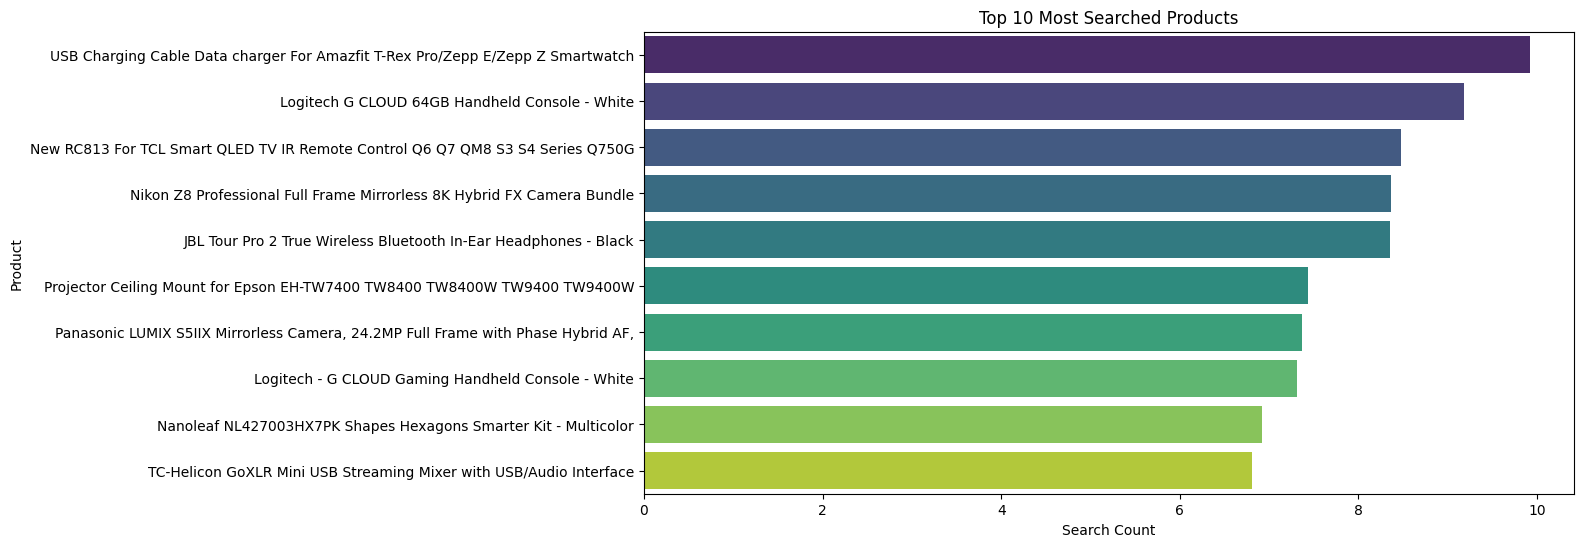

In [61]:
# 1. Bar Chart: Top 10 Most Searched Products
top_searched = df.groupby("Product")["Search_Count"].sum().nlargest(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_searched.values, y=top_searched.index, palette="viridis")
plt.xlabel("Search Count")
plt.ylabel("Product")
plt.title("Top 10 Most Searched Products")
plt.show()



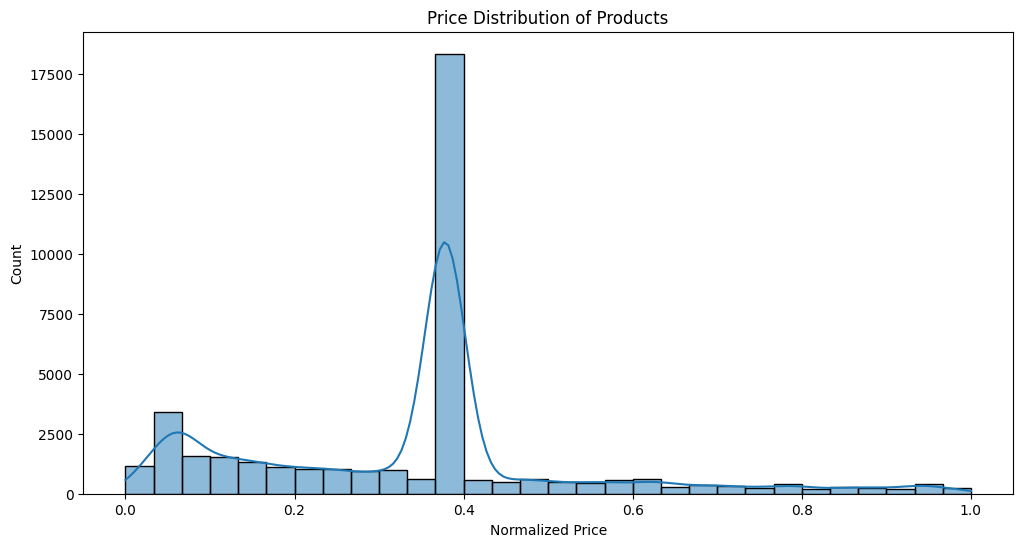

In [55]:
plt.figure(figsize=(12, 6))
sns.histplot(df["Price"], bins=30, kde=True)
plt.title("Price Distribution of Products")
plt.xlabel("Normalized Price")
plt.ylabel("Count")
plt.show()



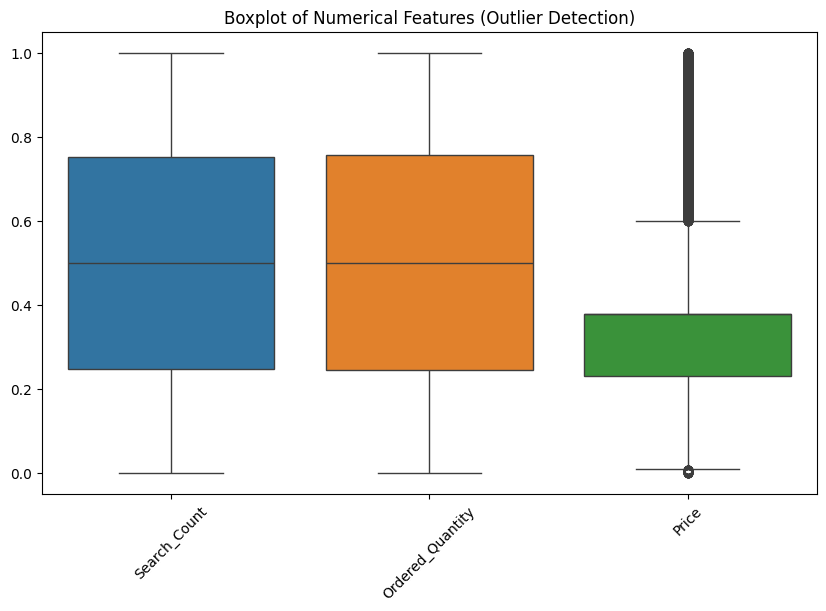

In [63]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[["Search_Count", "Ordered_Quantity", "Price"]])
plt.title("Boxplot of Numerical Features (Outlier Detection)")
plt.xticks(rotation=45)
plt.show()


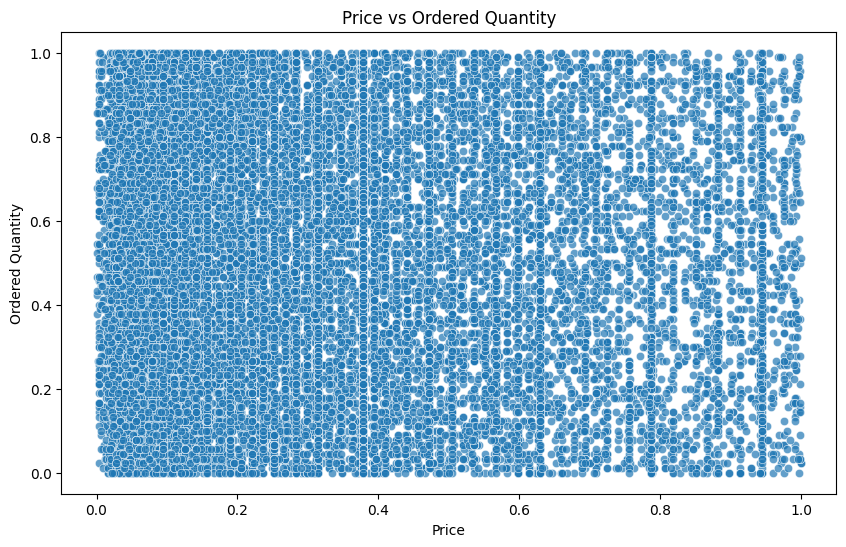

In [65]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["Price"], y=df["Ordered_Quantity"], alpha=0.7)
plt.xlabel("Price")
plt.ylabel("Ordered Quantity")
plt.title("Price vs Ordered Quantity")
plt.show()


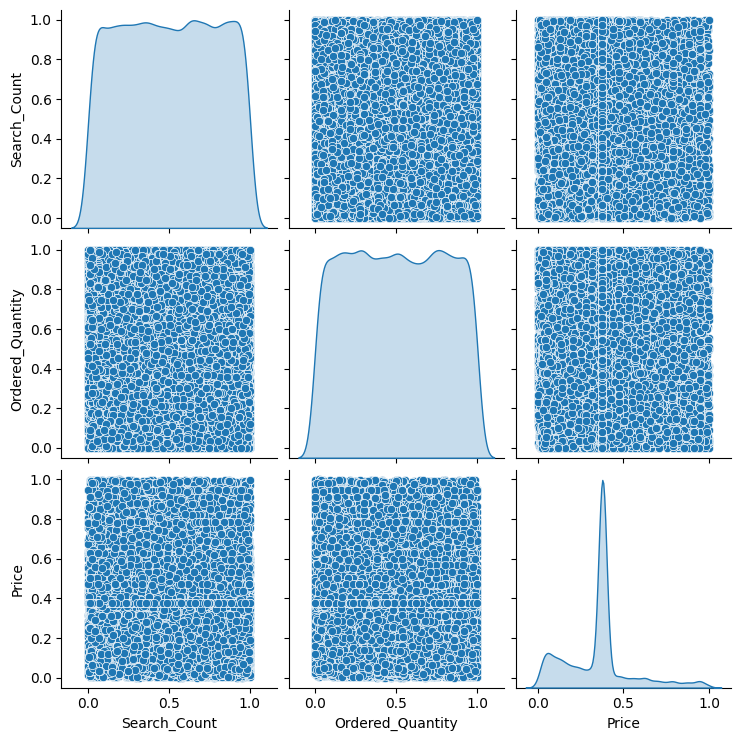

In [66]:
sns.pairplot(df[["Search_Count", "Ordered_Quantity", "Price"]], diag_kind="kde")
plt.show()


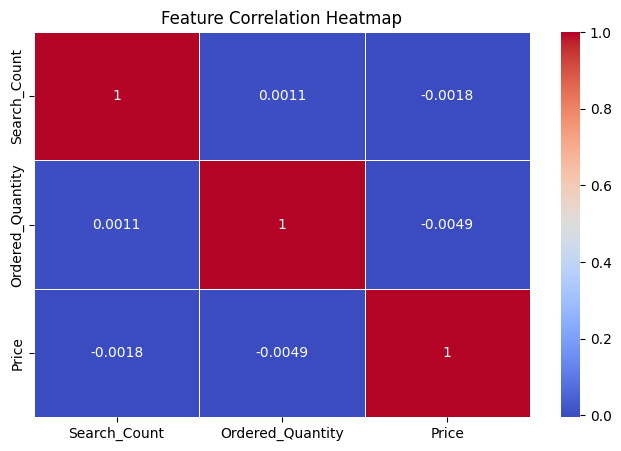

In [67]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[["Search_Count", "Ordered_Quantity", "Price"]].corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()
